# Stroke Rehabilitation — Energy Analysis

This notebook analyses wrist accelerometer data from QSense sensors. It automatically removes walking periods using a trained model (StrokeNet) and then calculates energy expenditure for the remaining movements.

**Instructions:** First upload the patient data to the **Data** folder.  Run each cell in order by clicking it and pressing `Shift + Enter`, or use the ▶▶ button above to run all cells at once. You only need to fill in the three boxes in Step 2. The final plots and results excel can be found in the the **Results** folder.

> Before running, please ensure you have uploaded the patient data to their respective folder under 'Data'. Adhere to the data naming guideline of 'Name_Date' (i.e. patientA_yyyymmdd)

## Step 0 — install packages

Run the cell below **once** the first time you use this notebook on a new machine. After it finishes, restart the kernel (`Kernel → Restart Kernel`) and then run from Step 1 downwards.

> If your institution's JupyterHub already has these packages, you can skip this cell.

In [ ]:
import sys
!{sys.executable} -m pip install torch --index-url https://download.pytorch.org/whl/cpu
!{sys.executable} -m pip install pandas numpy matplotlib ipywidgets openpyxl scipy scikit-learn
!{sys.executable} -m pip install jupyter_contrib_nbextensions
!jupyter labextension enable @jupyter-widgets/jupyterlab-manager 2>/dev/null || true
print("\n✓  All packages installed.")
print("   → Now go to Kernel → Restart Kernel, then run from Step 1.")


---
## Step 1 — Setup
Load the model and libraries. This only needs to run once per session.

In [1]:
import os, sys, warnings, torch
warnings.filterwarnings('ignore')
import ipywidgets as widgets
from IPython.display import display, FileLink, clear_output, Image

# Works wherever the folder is placed — no hardcoded paths
NOTEBOOK_DIR  = os.path.dirname(os.path.abspath('__file__'))
sys.path.insert(0, NOTEBOOK_DIR)

import helper_functions as hf

DATA_DIR     = os.path.join(NOTEBOOK_DIR, 'Data')
WEIGHTS_PATH = os.path.join(NOTEBOOK_DIR, 'eldernet_finetuned.pth')
RESULTS_DIR  = os.path.join(NOTEBOOK_DIR, 'Results')   # sibling of Data/
os.makedirs(RESULTS_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = hf.load_finetuned_model(WEIGHTS_PATH).to(device)
print(f'✓ Ready — running on {device}')
print(f'✓ Results will be saved to: {RESULTS_DIR}')


Using cache found in /home/jovyan/.cache/torch/hub/yonbrand_ElderNet_main


137 Weights loaded
Loaded finetuned weights from /home/jovyan/Herwin/Energy Analysis/eldernet_finetuned.pth
✓ Ready — running on cpu
✓ Results will be saved to: /home/jovyan/Herwin/Energy Analysis/Results


---
## Step 2 — Patient Settings

Select the **patient data folder** in Data, their **affected wrist** and enter their **target (non-walking) energy**, then click **Confirm**.

In [5]:
# 1. Identify the Data Directory
DATA_DIR = os.path.join(NOTEBOOK_DIR, 'Data')

# 2. Select Patient
patients = [f for f in sorted(os.listdir(DATA_DIR))
            if os.path.isdir(os.path.join(DATA_DIR, f)) and not f.startswith(".")]
if not patients:
    print(f"⚠️  No patient folders found in {DATA_DIR}")
else:
    print(f"Found {len(patients)} patient(s): {', '.join(patients)}")

selected_patient = input("Which patient are you analysing? ").strip()
patient_folder   = os.path.join(DATA_DIR, selected_patient)
if not os.path.isdir(patient_folder):
    print(f"❌ Patient folder not found: {patient_folder}")

# 3. Select a single day to process
days = [d for d in sorted(os.listdir(patient_folder))
        if os.path.isdir(os.path.join(patient_folder, d)) and not d.startswith(".")]
if not days:
    print(f"⚠️  No day folders found in {patient_folder}")
else:
    print(f"\nFound {len(days)} day(s): {', '.join(days)}")

selected_day = input("Which day are you analysing? (type specific folder name or 'most recent') ").strip()
if selected_day.lower() == 'most recent':
    selected_day = days[-1]
    print(f"  Using most recent day: {selected_day}")
day_folder = os.path.join(patient_folder, selected_day)
if not os.path.isdir(day_folder):
    print(f"❌ Day folder not found: {day_folder}")
else:
    print(f"✓  Day folder: {day_folder}")

# 4. How many previous days to show in the multi-day plot
n_input = input("\nHow many previous days in the multi-day plot? (2, 3, 4... or 'all'): ").strip()
n_days  = 'all' if n_input.lower() == 'all' else n_input

# 5. Select Wrist
wrist_map   = {'r': 'right', 'right': 'right', 'l': 'left', 'left': 'left'}
wrist_input = None
while wrist_input is None:
    wrist_input = wrist_map.get(input("\nAffected wrist (right/left): ").strip().lower())
    if wrist_input is None:
        print("❌ Please enter 'right' or 'left'.")

# 6. Select Target Energy
while True:
    try:
        target_val = float(input("Target energy: ").strip())
        if target_val < 0:
            print("❌ Target must be 0 or greater.")
            continue
        break
    except ValueError:
        print("❌ Please enter a number.")

# 7. Select Target Ratio
while True:
    try:
        target_ratio = float(input("Target ratio (%): ").strip())
        if target_ratio < 0:
            print("❌ Target must be 0 or greater.")
            continue
        break
    except ValueError:
        print("❌ Please enter a number.")


# Store everything
confirmed = {
    'patient':        selected_patient,
    'patient_folder': patient_folder,
    'day':            selected_day,
    'day_folder':     day_folder,
    'n_days':         n_days,
    'wrist':          wrist_input,
    'target':         target_val,
    'target_ratio':   target_ratio,
}
print(f"\n✅ Ready: {confirmed['patient']} | {confirmed['day']} | "
      f"{confirmed['wrist']} wrist | target energy: {confirmed['target']} | target ratio: {confirmed['target_ratio']} |"
      f"multi-day window: {confirmed['n_days']}")


Found 2 patient(s): PatientA, PatientB


Which patient are you analysing?  PatientA



Found 4 day(s): patientA_20260310, patientA_20260317, patientA_20260319, patientA_20260325


Which day are you analysing? (type specific folder name or 'most recent')  patientA_20260310


✓  Day folder: /home/jovyan/Herwin/Energy Analysis/Data/PatientA/patientA_20260310



How many previous days in the multi-day plot? (2, 3, 4... or 'all'):  all

Affected wrist (right/left):  right
Target energy:  10000000
Target ratio (%):  50



✅ Ready: PatientA | patientA_20260310 | right wrist | target energy: 10000000.0 | target ratio: 50.0 |multi-day window: all


---
## Step 3 — Run Analysis

Processes the selected day through the model and caches the result.

In [6]:
if 'confirmed' not in locals():
    print("❌ Please complete Step 2 first.")
else:
    print(f"Processing {confirmed['day']} for {confirmed['patient']} ...")

    result = hf.run_subject(
        confirmed['day'],
        confirmed['day_folder'],
        model,
        device,
        confirmed['patient'],
    )

    results = [result] if result is not None else []

    if not results:
        print("❌ No valid data found in the selected day folder.")
    else:
        hf.save_day_cache(result, confirmed['patient_folder'],
                          confirmed['wrist'], confirmed['target'])
        print(f"\n✓ Analysis complete for {confirmed['day']}")


Processing patientA_20260310 for PatientA ...
  Cached: /home/jovyan/Herwin/Energy Analysis/Data/PatientA/.cache/patientA_20260310.pkl

✓ Analysis complete for patientA_20260310


---
## Step 4 — View and Save Results

Shows the hourly bar chart for today and the multi-day summary, and save an excel file for the chosen day with a detailed per window breakdown sheet as well as a summary sheet.

All outputs are saved to the `Results/` folder next to `Data/`.

── Today's hourly energy ──


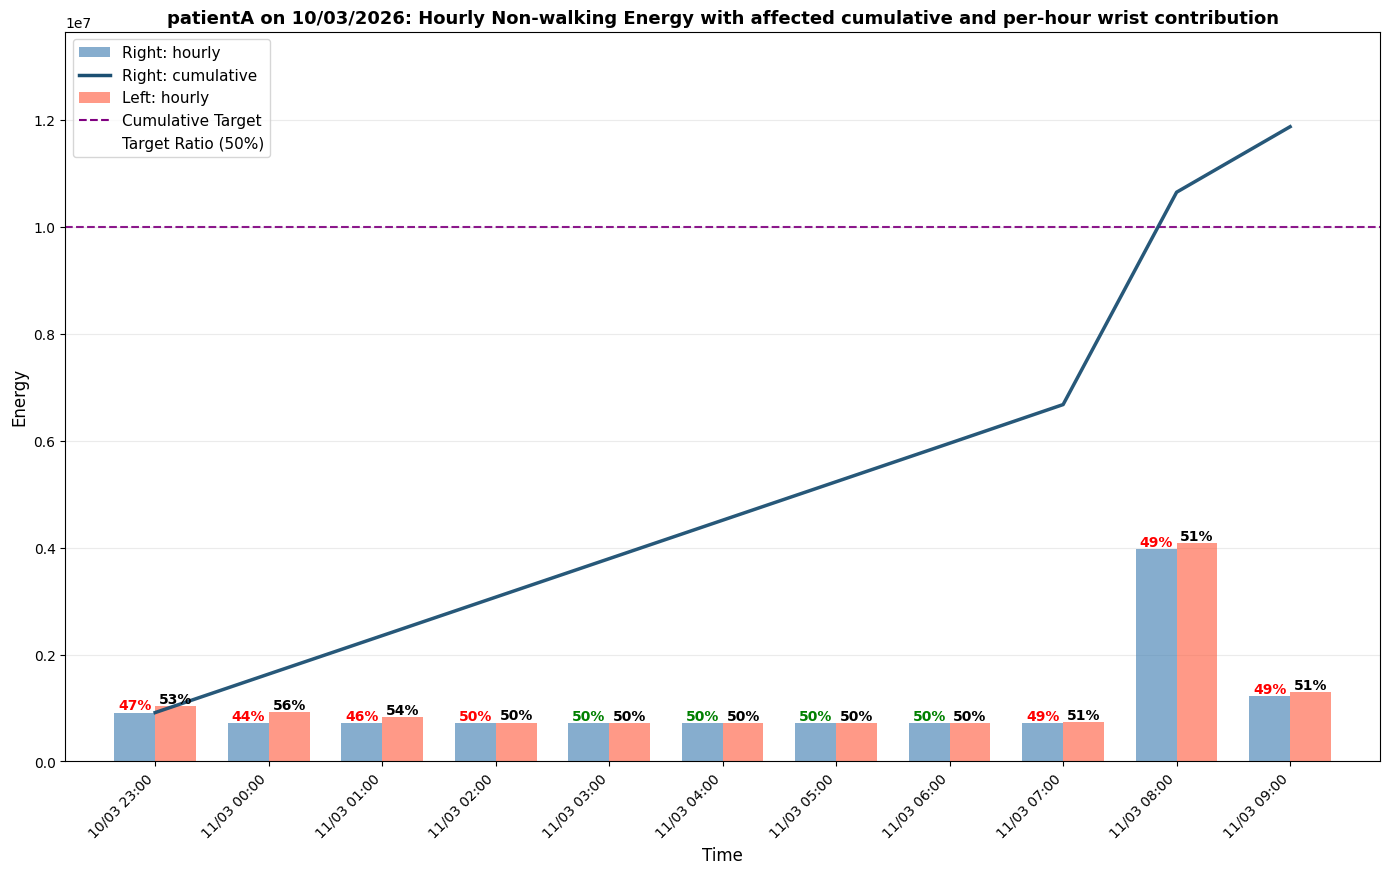

  Saved: /home/jovyan/Herwin/Energy Analysis/Results/PatientA/Day Plots/patientA_20260310.png

── Multi-day summary ──


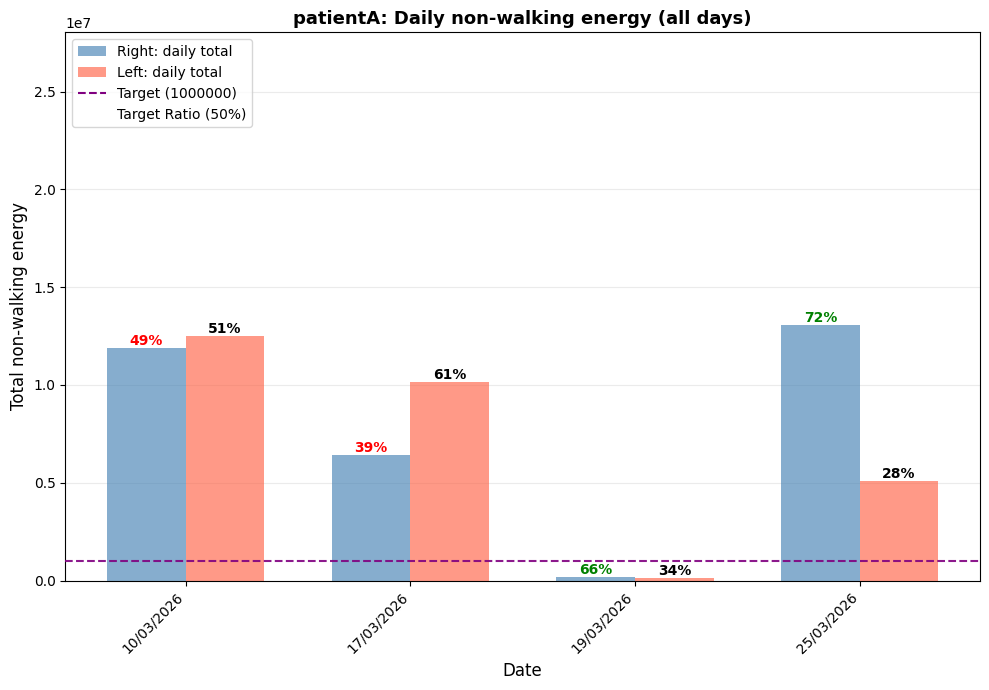

  Saved: /home/jovyan/Herwin/Energy Analysis/Results/PatientA/Multiday Plots/patientA_20260310-20260325.png
  Saved: /home/jovyan/Herwin/Energy Analysis/Results/PatientA/Excel/patientA_20260310_energy.xlsx (72563 windows)


In [7]:
if not results:
    print("❌ No results found. Run Step 3 first.")
else:
    r = results[0]

    %matplotlib inline

    # ── Plot 1: hourly bar chart for today ────────────────────────────────
    hourly_dir = os.path.join(RESULTS_DIR, confirmed['patient'], 'Day Plots')
    os.makedirs(hourly_dir, exist_ok=True)
    print("── Today\'s hourly energy ──")
    hf.plot_energy_results_bar([r], hourly_dir, confirmed['wrist'], confirmed['target'], confirmed['target_ratio'])

    # ── Plot 2: multi-day summary (loads cache, no reprocessing) ─────────
    multiday_dir = os.path.join(RESULTS_DIR, confirmed['patient'], 'Multiday Plots')
    print("\n── Multi-day summary ──")
    hf.plot_multiday(confirmed['patient_folder'], multiday_dir, n_days=confirmed['n_days'], target_ratio = confirmed['target_ratio'])

    # ── Excel export ──────────────────────────────────────────────────────
    excel_dir = os.path.join(RESULTS_DIR, confirmed['patient'], 'Excel')
    hf.save_subject_excel(r, excel_dir, confirmed['wrist'], confirmed['target'], confirmed['target_ratio'])
    xlsx_path = os.path.join(excel_dir, f"{confirmed['day']}_energy.xlsx")
